# Introdução 

## Contexto

O serviço de telefonia virtual CallMeMaybe está desenvolvendo uma nova funcionalidade que permitirá aos supervisores **identificar operadores menos eficientes**.

Os clientes da empresa são **organizações que precisam gerenciar grandes volumes de chamadas** — tanto recebidas quanto realizadas por diversos operadores.

De acordo com as regras de negócio, um operador é considerado **ineficiente** se:

- Possui **muitas chamadas recebidas perdidas** (internas ou externas);
- Apresenta **tempo de espera prolongado** nas chamadas recebidas;
- E, no caso de operadores responsáveis por chamadas de saída, realiza **poucas chamadas ativas**.

## Dados

O dataset compactado **`telecom_dataset_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID da conta do cliente
- **`date`**: data em que as estatísticas foram coletadas
- **`direction`**: “direção” da chamada (`out` para chamadas **saídas**, `in` para chamadas **entrantes**)
- **`internal`**: indica se a chamada foi **interna** (entre operadores de um mesmo cliente)
- **`operator_id`**: identificador do operador
- **`is_missed_call`**: indica se foi uma **chamada perdida**
- **`calls_count`**: número de chamadas
- **`call_duration`**: duração da chamada (sem incluir o tempo de espera)
- **`total_call_duration`**: duração total da chamada (incluindo o tempo de espera)

O conjunto de dados **`telecom_clients_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID do cliente
- **`tariff_plan`**: plano tarifário atual do cliente
- **`date_start`**: data de registro do cliente

## Objetivo 

O objetivo da análise será averiguar a eficiência dos operadores de acordo com as orientações base fornecidas pela companhia para oferecer ao fim uma avaliação confiável para tomada de decisão.

# Setup e Dados

## Ambiente

### Importação bibliotecas

In [1]:
# importação de bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import stats as st 
import warnings 

### Configurações Globais

In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

### Carregamento de dados

In [3]:
# leitura primeiro dataset
telecom = pd.read_csv('../datasets/telecom_dataset_new.csv')

In [4]:
# leitura segundo dataset
clients = pd.read_csv('../datasets/telecom_clients.csv')

## Pré Processamento 

### Primeiras impressões

In [5]:
# primeira visualização
telecom.head(10)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.00,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.00,True,3,0,25
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,False,2,3,29
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62


In [6]:
# descoberta informações sobre os dados  
telecom.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB


In [7]:
# descoberta características dos dados
telecom.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,53902.00,167295.34,598.88,166377.00,166782.00,167162.00,167819.00,168606.00
operator_id,45730.00,916535.99,21254.12,879896.00,900788.00,913938.00,937708.00,973286.00
calls_count,53902.00,16.45,62.92,1.00,1.00,4.00,12.00,4817.00
call_duration,53902.00,866.68,3731.79,0.00,0.00,38.00,572.00,144395.00
total_call_duration,53902.00,1157.13,4403.47,0.00,47.00,210.00,902.00,166155.00


O dataset *telecom* possui a nomenclatura de suas colunas dentro do padrão snake_case, encontram-se valores ausentes nas colunas *internal* e *operator_id* e seria mais adequado mudança no tipo de dado em colunas como *date* e *operator_id*.

In [8]:
# primeira visualização
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [9]:
# descoberta informações sobre os dados  
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB


In [10]:
# descoberta características dos dados  
clients.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,732.00,167431.93,633.81,166373.00,166900.75,167432.00,167973.00,168606.00


O dataset *clients* possui a nomenclatura de suas colunas dentro do padrão snake_case, não encontram-se valores ausentes e seria mais adequado mudança no tipo de dado na coluna *date_start*.  

### Valores duplicados

In [11]:
# # descoberta quantidade de registros duplicados dataset clients
clients.duplicated().sum()

np.int64(0)

In [12]:
# descoberta quantidade de registros duplicados dataset telecom
telecom.duplicated().sum()

np.int64(4900)

In [13]:
# visualização de registros duplicados
telecom[telecom.duplicated()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
44,166377,2019-08-14 00:00:00+03:00,out,False,880026.00,False,10,1567,1654
45,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
51,166377,2019-08-15 00:00:00+03:00,out,False,880026.00,False,11,1413,1473
...,...,...,...,...,...,...,...,...,...
53869,168601,2019-11-25 00:00:00+03:00,in,False,952914.00,False,7,1229,1282
53874,168601,2019-11-26 00:00:00+03:00,in,False,952914.00,False,4,539,562
53875,168601,2019-11-26 00:00:00+03:00,in,False,NaN,True,3,0,35
53885,168603,2019-11-20 00:00:00+03:00,out,False,959118.00,True,3,0,89


In [14]:
# eliminação registros duplicados
telecom = telecom.drop_duplicates().reset_index(drop=True)

4900 registros (~9% dos dados) foram deletados por se tratarem de duplicatas. Não aparenta possuir um padrão claro de repetição.

### Valores nulos

In [15]:
# descoberta quantidade registros ausentes dataset clients
clients.isnull().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

In [16]:
# descoberta quantidade registros ausentes dataset telecom
telecom.isnull().sum()

user_id                   0
date                      0
direction                 0
internal                110
operator_id            7456
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [17]:
# visualização de registros duplicados
telecom[telecom['internal'].isnull()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
917,166405,2019-09-18 00:00:00+03:00,in,NaN,NaN,True,1,0,59
996,166405,2019-10-01 00:00:00+03:00,in,NaN,NaN,True,1,0,1
1705,166406,2019-08-20 00:00:00+03:00,in,NaN,NaN,True,1,0,36
1761,166406,2019-09-02 00:00:00+03:00,in,NaN,879898.00,False,1,2,9
5645,166541,2019-09-26 00:00:00+03:00,in,NaN,908960.00,False,1,393,423
...,...,...,...,...,...,...,...,...,...
47702,168361,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,6,0,14
47819,168361,2019-11-13 00:00:00+03:00,in,NaN,NaN,True,2,0,6
47844,168361,2019-11-14 00:00:00+03:00,in,NaN,NaN,True,1,0,2
48837,168579,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,1,0,18


In [18]:
# visualização de registros duplicados
telecom[telecom['operator_id'].isnull()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62
16,166377,2019-08-07 00:00:00+03:00,in,False,NaN,True,2,0,24
26,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
...,...,...,...,...,...,...,...,...,...
48978,168601,2019-11-27 00:00:00+03:00,in,False,NaN,True,2,0,39
48982,168601,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,19
48990,168603,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,30
48994,168606,2019-11-08 00:00:00+03:00,in,False,NaN,True,6,0,121


In [19]:
# 
telecom[telecom['operator_id'].isnull()]['is_missed_call'].value_counts()

is_missed_call
True     7343
False     113
Name: count, dtype: int64

A maioria esmagadora de valores nulos na coluna 'operator_id' possuem 'is_missed_call' == True. 

Esse fato pode ser derivado de um erro sistêmico ou chamadas que nem sequer foram atribuídas a um operador (erro sistêmico). 

In [20]:
# exclusão valores nulos
telecom = telecom.dropna()  

Cerca de 7500 registros (~15% dos dados) foram deletados por possível erro sistêmico. 

### Ajuste tipo de dado

In [21]:
# ajuste tipo de dado 'date'
telecom['date'] = pd.to_datetime(telecom['date'])

In [22]:
# ajuste fuso horário
telecom['date'] = telecom['date'].dt.tz_convert('Europe/Lisbon')

In [23]:
# ajuste date_start
clients['date_start'] = pd.to_datetime(clients['date_start'])

### Criação novas colunas

In [24]:
# criação coluna 'waiting_time'
telecom['waiting_time'] = telecom['total_call_duration'] - telecom['call_duration']

In [25]:
# criação coluna 'month'
telecom['month'] = telecom['date'].dt.month 

In [26]:
telecom['week'] = telecom['date'].dt.isocalendar().week 

In [27]:
# criação coluna 'day'
telecom['day'] = telecom['date'].dt.day

In [85]:
# criação coluna 'week'
telecom['day_of_week'] = telecom['date'].dt.dayofweek

In [29]:
# criação coluna 'is_weekend'
telecom['is_weekend'] = telecom['day_of_week'].isin([5,6]).astype(int)

In [30]:
# criação coluna 'hour'
telecom['hour'] = telecom['date'].dt.hour

In [31]:
print(telecom['month'].nunique())
print(telecom['day'].nunique())
print(telecom['day_of_week'].nunique())
print(telecom['hour'].nunique()) 

4
31
7
2


Não será possível analisar a variação de horas, tratam-se de dados agregados diariamente.

In [32]:
telecom = telecom.drop(columns='hour')

# Análise Exploratória de Dados

## Volumes e Proporções gerais

### Volume mensal de chamadas

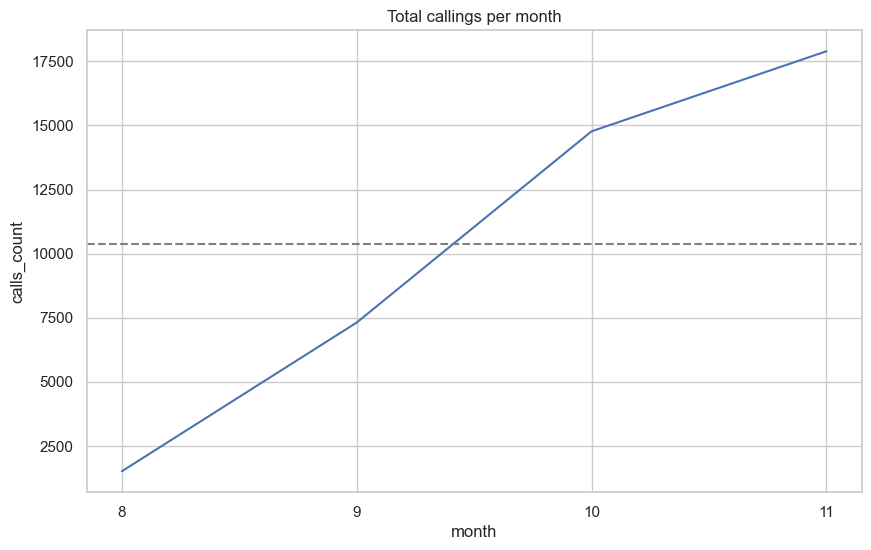

Média mensal de chamadas: 10372.75


In [133]:
# criação de gráfico de linhas
sns.lineplot(data=telecom.groupby('month')['calls_count'].count().reset_index(), x='month', y='calls_count')
plt.title('Total callings per month')
plt.xticks(telecom['month'].unique())
plt.axhline(y=(telecom['calls_count'].count() / telecom['month'].nunique()), color='gray', linestyle='--')
plt.show()
print(f"Média mensal de chamadas: {telecom['calls_count'].count() / telecom['month'].nunique():.2f}")

Aumento exponencial do volume de chamadas ao longo do período (de aproximadamente 2500 chamadas para 17500 chamadas, cerca de 600%).

### Volume semanal de chamadas

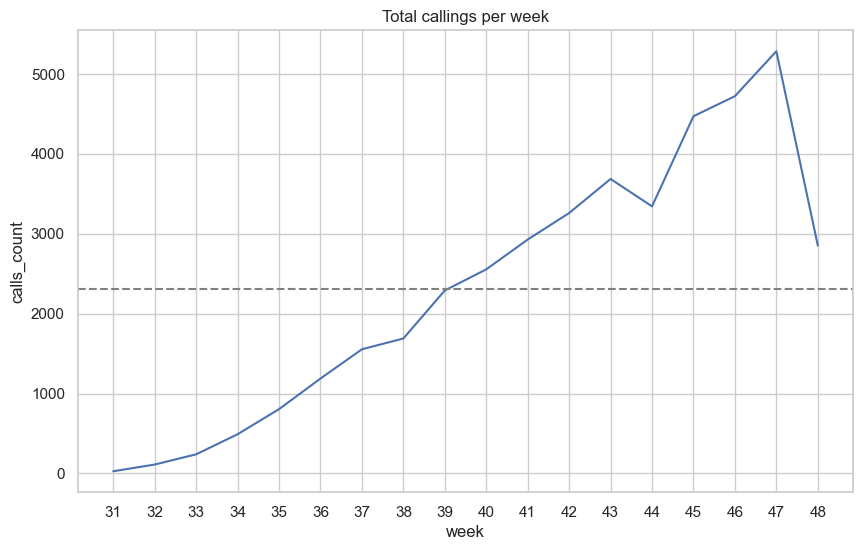

Média semanal de chamadas: 2305.06


In [134]:
# criação gráfico de linhas
sns.lineplot(data=telecom.groupby('week')['calls_count'].count().reset_index(), x='week', y='calls_count')
plt.title('Total callings per week')
plt.xticks(telecom['week'].unique())
plt.axhline(y=(telecom['calls_count'].count() / telecom['week'].nunique()), color='gray', linestyle='--')
plt.show()
print(f"Média semanal de chamadas: {telecom['calls_count'].count() / telecom['week'].nunique():.2f}")

O crescimento do volume de chamadas reafirma o padrão visto dentro do volume mensal, mas com o detalhe de que já nas últimas semanas estava acontecendo um declínio.

### Volume diário de chamadas

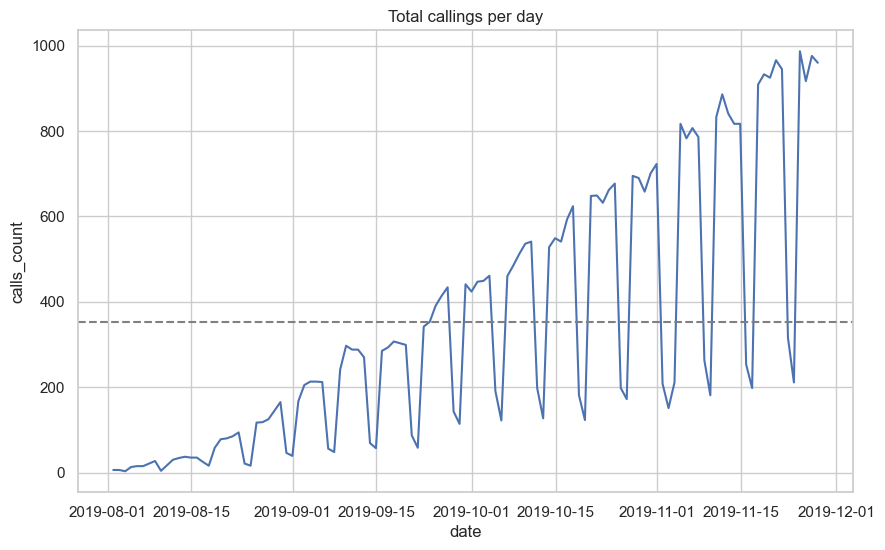

Média diária de chamadas: 351.62


In [135]:
# criação gráfico de linhas
sns.lineplot(data=telecom.groupby('date')['calls_count'].count().reset_index(), x='date', y='calls_count')
plt.title('Total callings per day')
plt.axhline(y=(telecom['calls_count'].count() / telecom['date'].nunique()), color='gray', linestyle='--')
plt.show()
print(f"Média diária de chamadas: {telecom['calls_count'].count() / telecom['date'].nunique():.2f}")

Visualização do mesmo padrão visto anteriormente, as oscilações devem-se referir aos dias de menor volume de chamadas (fins de semana).

### Proporção de chamadas por dia da semana

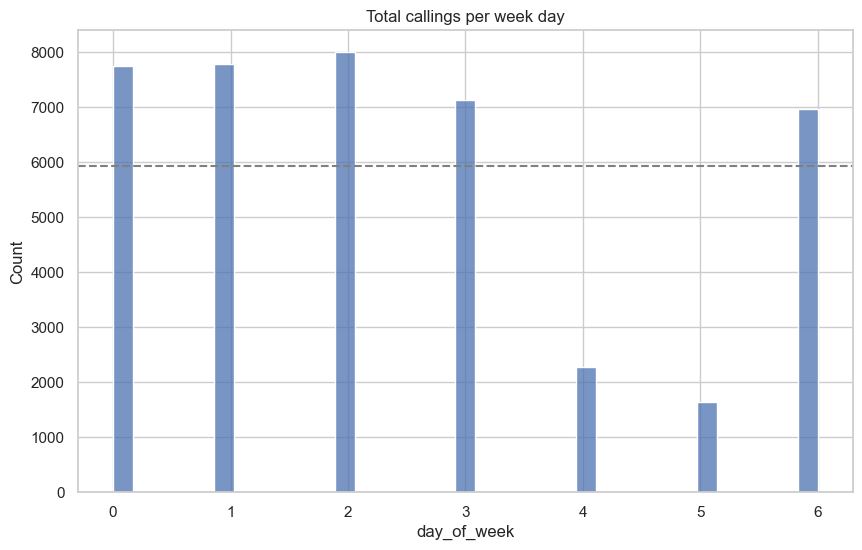

Porcentagem de chamadas no dia 6: 16.79%
Porcentagem de chamadas no dia 0: 18.66%
Porcentagem de chamadas no dia 1: 18.73%
Porcentagem de chamadas no dia 2: 19.27%
Porcentagem de chamadas no dia 3: 17.15%
Porcentagem de chamadas no dia 4: 5.46%
Porcentagem de chamadas no dia 5: 3.94%


In [136]:
# criação histplot
sns.histplot(telecom['day_of_week'])
plt.title('Total callings per week day')
plt.axhline(y=(telecom['calls_count'].count() / telecom['day_of_week'].nunique()), color='gray', linestyle='--')
plt.show()
for x in telecom['day_of_week'].unique():
    print(f"Porcentagem de chamadas no dia {x}: {(telecom[telecom['day_of_week'] == x].shape[0] / telecom.shape[0]) * 100:.2f}%")

Sexta-feira e sábado são os dias com menores volume de chamadas.

Finais de semana representam cerca de 20% das chamadas.

### Proporção chamadas inbound e outbound

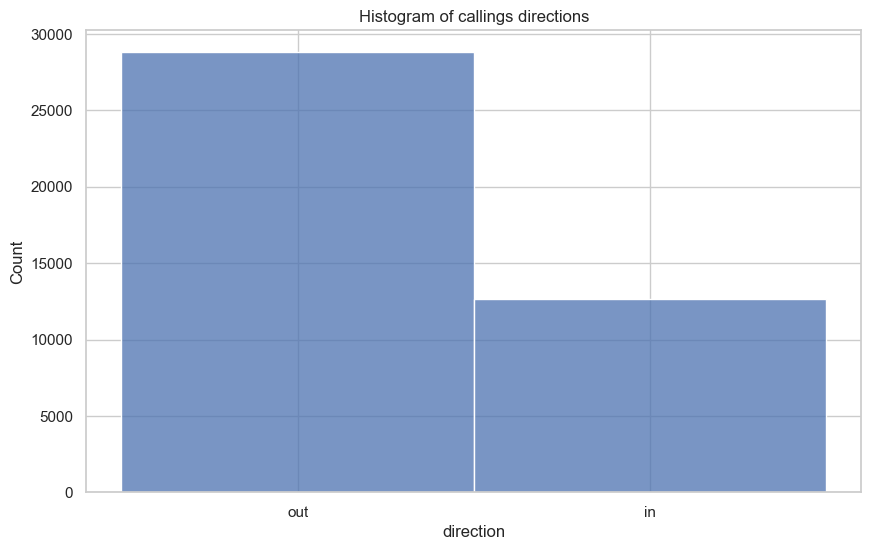

Porcentagem de chamadas outbound: 69.44%
Porcentagem de chamadas inbound: 30.56%


In [146]:
# criação histograma
sns.histplot(telecom['direction'])
plt.title('Histogram of callings directions')
plt.xticks(telecom['direction'].unique())
plt.show()
print(f"Porcentagem de chamadas outbound: {(telecom[telecom['direction'] == 'out'].shape[0] / telecom.shape[0]) * 100:.2f}%")
print(f"Porcentagem de chamadas inbound: {(telecom[telecom['direction'] == 'in'].shape[0] / telecom.shape[0]) * 100:.2f}%")

Chamadas outbound representam a maioria dos dados (aproximadamente 70% x 30%).

### Proporção chamadas internas e externas

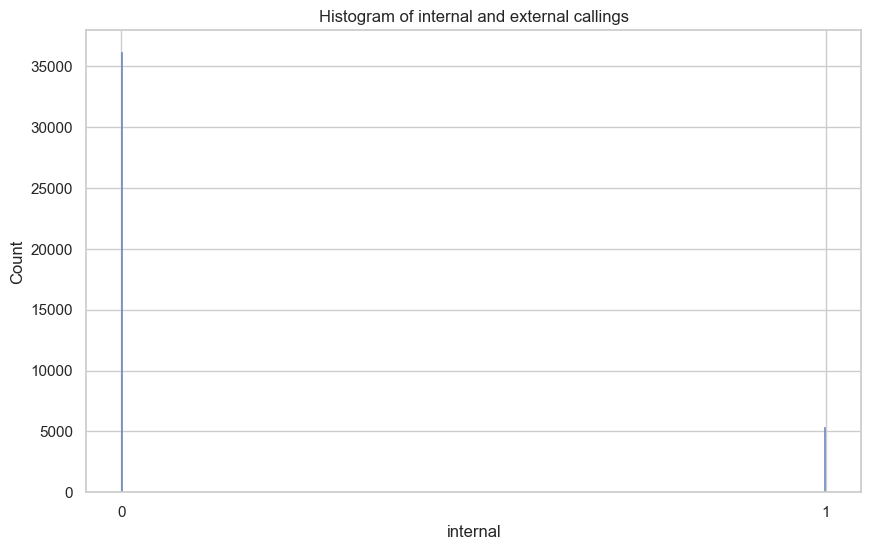

Porcentagem de chamadas externas: 87.15%
Porcentagem de chamadas internas: 12.85%


In [139]:
# criação histograma
sns.histplot(telecom['internal'])
plt.title('Histogram of internal and external callings')
plt.xticks([0, 1])
plt.show()
print(f"Porcentagem de chamadas externas: {(telecom[telecom['internal'] == False].shape[0] / telecom.shape[0]) * 100:.2f}%")
print(f"Porcentagem de chamadas internas: {(telecom[telecom['internal'] == True].shape[0] / telecom.shape[0]) * 100:.2f}%")

As proporções de chamadas internas x externas são desbalanceadas (87,15% x 12,85%).

### não fiz mas está na decomposição

In [ ]:
# descoberta da mediana de chamadas por *'operator_id'* por semana


In [ ]:
# descoberta do número total de chamadas por operator_id


## Chamadas recebidas perdidas 

### Identificação entre *'operator_id'* que apresentam maior mediana semanal de *'is_missed_call'* para *'direction'* == *'in'*

In [142]:
# identificação entre *'operator_id'* que apresentam maior mediana semanal de *'is_missed_call'* para *'direction'* == *'in'*
telecom[telecom['direction'] == 'in'].groupby('is_missed_call')['calls_count'].count()

is_missed_call
False    11994
True       684
Name: calls_count, dtype: int64

### Descoberta de mediana semanal sobre *'is_missed_call'* entre operadores para *'direction'* == *'in'*


In [ ]:
# descoberta de mediana semanal sobre *'is_missed_call'* entre operadores para *'direction'* == *'in'*


### Proporção de 'is_missed_call' entre chamadas internas e externas para 'direction' == 'in'

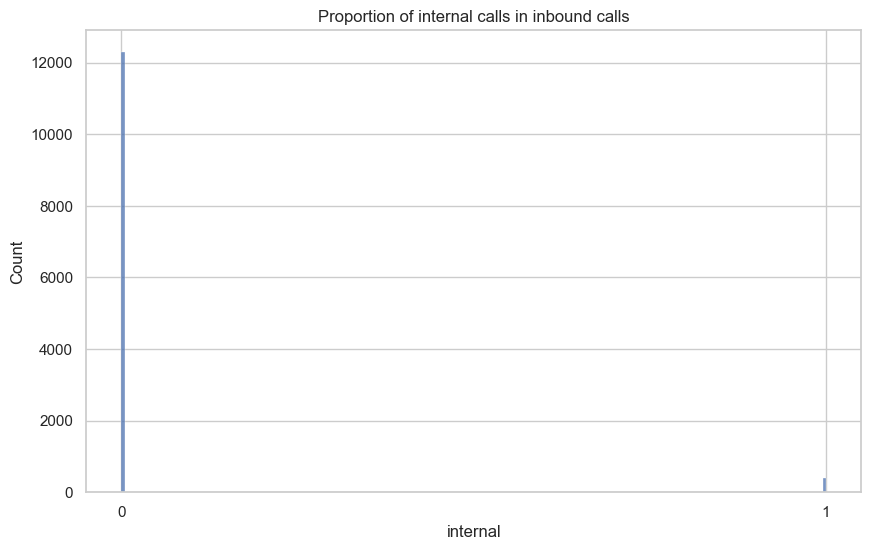

Porcentagem de chamadas inbound externas: 96.96%
Porcentagem de chamadas inbound internas: 3.04%


In [153]:
# criação histograma
sns.histplot(telecom[telecom['direction'] == 'in']['internal'])
plt.title('Proportion of internal calls in inbound calls')
plt.xticks([0, 1])
plt.show()
print(f"Porcentagem de chamadas inbound externas: {(telecom[(telecom['internal'] == False) & (telecom['direction'] == 'in')].shape[0] / telecom[telecom['direction'] == 'in'].shape[0]) * 100:.2f}%")
print(f"Porcentagem de chamadas inbound internas: {(telecom[(telecom['internal'] == True) & (telecom['direction'] == 'in')].shape[0] / telecom[telecom['direction'] == 'in'].shape[0]) * 100:.2f}%")


### Correlação entre 'is_missed_call' e 'waiting_time' para para 'direction' == 'in'

In [ ]:
# identificação de correlação entre 'is_missed_call' e 'waiting_time' para para 'direction' == 'in'


## Tempo de espera chamadas recebidas

In [ ]:
# identificação entre 'operator_id' que apresentam com maior mediana semanal de 'waiting_time' para 'direction' == 'in'


In [ ]:
# descoberta mediana sobre 'waiting_time' entre operadores para 'direction' == 'in'


In [ ]:
# identificação de correlação entre 'waiting_time' e 'internal' para 'direction' == 'in'


In [ ]:
# identificação de correlação entre 'call_duraction' e 'waiting_time'


## Chamadas de saída ativas

In [ ]:
# identificação entre 'operator_id' com menores números semanais de chamadas para 'direction' == 'out'


In [ ]:
# descoberta média/mediana semanal do número de chamadas entre 'operator_id' e 'direction' == 'out'


In [ ]:
# identificação entre 'operator_id' com menor mediana de call_duration' para 'direction' == 'out'


In [ ]:
# descoberta mediana 'call_duration' entre 'operator_id' e 'direction' == 'out'


# Cálculo KPIs e Identificação de Ineficiência 

## Definições

In [ ]:
# criação de tabela agregada com dados de cada operador mediante váriaveis temporais (dia, semana): 'total_calls', 'missed_calls', 'avg_waiting_time', 'total_outbound_calls'

###  Ratio chamadas perdidas > 75

In [ ]:
# criação coluna 'missed_rate' baseada em fórmula de comparação entre 'operator_id':

# total de chamadas perdidas / total de chamadas recebidas

# os 'operator_id' com ratio acima do percentil 75 da equipe serão adicionados à variável 'highers_missed_rate'

### Tempo de espera > 75

In [ ]:
# os *'operator_id'* com períodos de espera acima do percentil 75 da equipe serão adicionados à variável *'highers_waiting_time'*

### Chamadas outbound < 25

In [ ]:
# os *'operator_id'* com número de chamadas abaixo do percentil 25 da equipe serão adicionados à variável *'lowers_outbound_calls'*

## Testes Estatísticos

# Conclusão e Recomendações de Negócio